In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyomo.environ import ConcreteModel, Set, Param, Var, Objective, Constraint, SolverFactory, NonNegativeReals, minimize, Reals, Binary, value



## Get Data

In [3]:
np.random.seed(40)  # Use any number you want

#get fixed data
def get_fixed_data():
    """
    Returns the fixed data for the energy hub simulation.
    """
    num_timeslots = 24
    return {
        # Conversion efficiencies
        'conversion_p2h': 0.9,
        'conversion_h2p': 0.8,

        # Hydrogen storage capacity
        'hydrogen_capacity': 15,
        
        'p2h_max_rate': 5,
        'h2p_max_rate': 5,

        # Electrolyzer cost
        'electrolyzer_cost': 1, 

        # Wind model parameters
        'target_mean_wind': 4.5,
        'wind_reversion_strength': 0.15,
        'extreme_event_prob_wind': 0.03,

        # Price model parameters
        'mean_price': 35,
        'price_reversion_strength': 0.12,
        'wind_influence_on_price': -0.6,
        'price_cap': 90,  
        'price_floor': 0,
        
        
        'num_timeslots': num_timeslots,
        'demand_schedule': [5 + 2 * np.sin(2 * np.pi * t / 24) for t in range(num_timeslots)]

        
    }

data = get_fixed_data()

def price_model(current_price, previous_price, projected_wind, data):
    """
    Price process with dependence on previous prices and projected wind generation.

    Args:
        current_price (float): Current electricity price.
        previous_price (float): Electricity price at the previous time step.
        projected_wind (float): Projected wind generation for the next time step.
        data (dict): Fixed data containing model parameters.

    Returns:
        float: Next price.
    """
    mean_price = data['mean_price']
    reversion_strength = data['price_reversion_strength']
    wind_influence = data['wind_influence_on_price']
    price_cap = data['price_cap']
    price_floor = data['price_floor']

    mean_reversion = reversion_strength * (mean_price - current_price)
    wind_effect = wind_influence * projected_wind
    noise = np.random.normal(0, 1)

    next_price = current_price + 0.6 * (current_price - previous_price) + mean_reversion + wind_effect + noise

    if next_price < 0:
        if np.random.rand() > 0.2:
            next_price = np.random.uniform(0, mean_price * 0.3)

    return max(min(next_price, price_cap), price_floor)

def wind_model(current_wind, data):
    """
    Wind generation process with mean reversion and extreme events.

    Args:
        current_wind (float): Current wind generation.
        data (dict): Fixed data containing model parameters.

    Returns:
        float: Next wind generation.
    """
    target_mean = data['target_mean_wind']
    reversion_strength = data['wind_reversion_strength']
    extreme_event_prob = data['extreme_event_prob_wind']

    mean_reversion = reversion_strength * (target_mean - current_wind)
    noise = np.random.normal(0, 1)

    next_wind = current_wind + mean_reversion + noise

    if np.random.rand() < extreme_event_prob:
        next_wind += np.random.uniform(10, 20)

    return max(next_wind, 0)

def simulate_energy_hub(data, num_steps):
    """
    Simulates the energy hub over a specified number of time steps.

    Args:
        data (dict): Fixed data containing model parameters.
        num_steps (int): Number of time steps to simulate.

    Returns:
        pd.DataFrame: DataFrame containing the simulation results.
    """
    results = {
        'time': [],
        'price': [],
        'wind_generation': [],
        'demand': []
    }

    current_price = data['mean_price']
    previous_price = current_price
    current_wind = data['target_mean_wind']

    for t in range(num_steps):
        projected_wind = wind_model(current_wind, data)
        next_price = price_model(current_price, previous_price, projected_wind, data)

        results['time'].append(t)
        results['price'].append(next_price)
        results['wind_generation'].append(projected_wind)
        results['demand'].append(data['demand_schedule'][t % data['num_timeslots']])

        previous_price = current_price
        current_price = next_price
        current_wind = projected_wind

    return pd.DataFrame(results)

# Run the simulation
#simulation_results = simulate_energy_hub(data, num_steps=100)
#print(simulation_results.head())


# 2 Stage Stochastic policy

## Generate scenarios


Correlation between Wind and Price: -0.4945


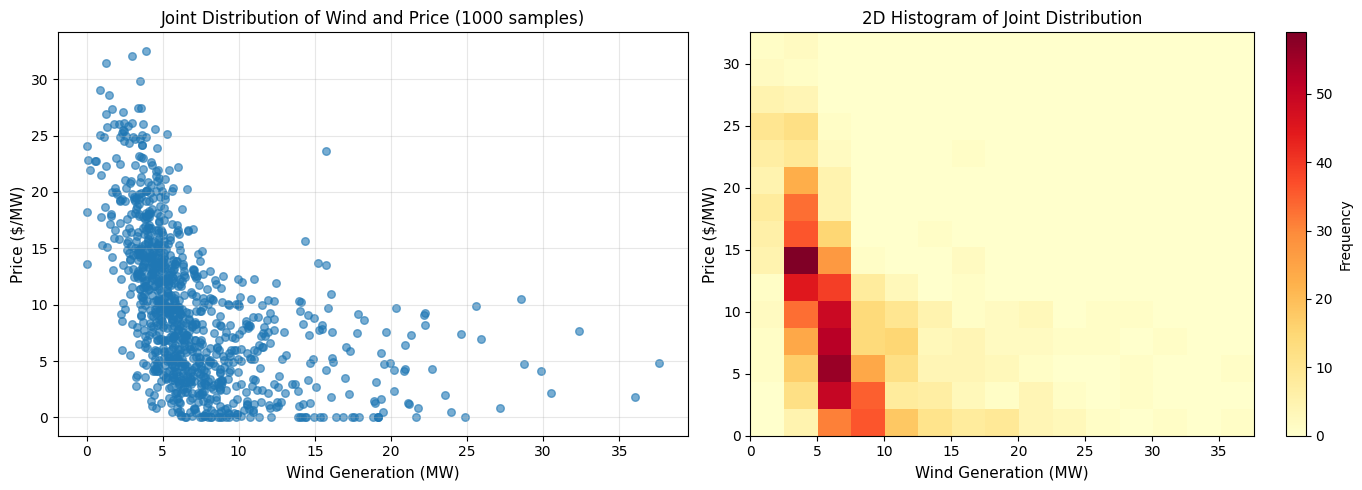

In [15]:
# Run wind_model and price_model in a loop 167 times to generate joint distribution
np.random.seed(40)

num_scenarios = 1000
data= get_fixed_data()
look_ahead_steps = 6

#start with a low number of scenarios to test the code, then increase it to 1000 or more for better statistics

def generate_scenarios(num_scenarios, data, look_ahead_steps):
    wind_values = []
    price_values = []

    # Initialize starting values
    current_wind = data['target_mean_wind']
    current_price = data['mean_price']
    previous_price = data['mean_price']

    # Run the loop
    for j in range(num_scenarios):
        # Call wind_model to get next wind generation
        current_wind = wind_model(current_wind, data)
        
        # Call price_model to get next price based on current price, previous price, and projected wind
        next_price = price_model(current_price, previous_price, current_wind, data)
        
        # Store the values
        wind_values.append(current_wind)
        price_values.append(next_price)
        
        # Update prices for next iteration
        previous_price = current_price
        current_price = next_price

    # Create a DataFrame for the joint distribution
    joint_dist_df = pd.DataFrame({
        'wind': wind_values,
        'price': price_values
    })



    print(f"\nCorrelation between Wind and Price: {np.corrcoef(wind_values, price_values)[0,1]:.4f}")

    # Visualize the joint distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(wind_values, price_values, alpha=0.6, s=30)
    axes[0].set_xlabel('Wind Generation (MW)', fontsize=11)
    axes[0].set_ylabel('Price ($/MW)', fontsize=11)
    axes[0].set_title(f'Joint Distribution of Wind and Price ({num_scenarios} samples)', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    # 2D histogram / heatmap
    axes[1].hist2d(wind_values, price_values, bins=15, cmap='YlOrRd')
    axes[1].set_xlabel('Wind Generation (MW)', fontsize=11)
    axes[1].set_ylabel('Price ($/MW)', fontsize=11)
    axes[1].set_title('2D Histogram of Joint Distribution', fontsize=12)
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='Frequency')

    plt.tight_layout()
    plt.show()


    return joint_dist_df

joint_dist_df = generate_scenarios(num_scenarios, data, look_ahead_steps)

## Clustering

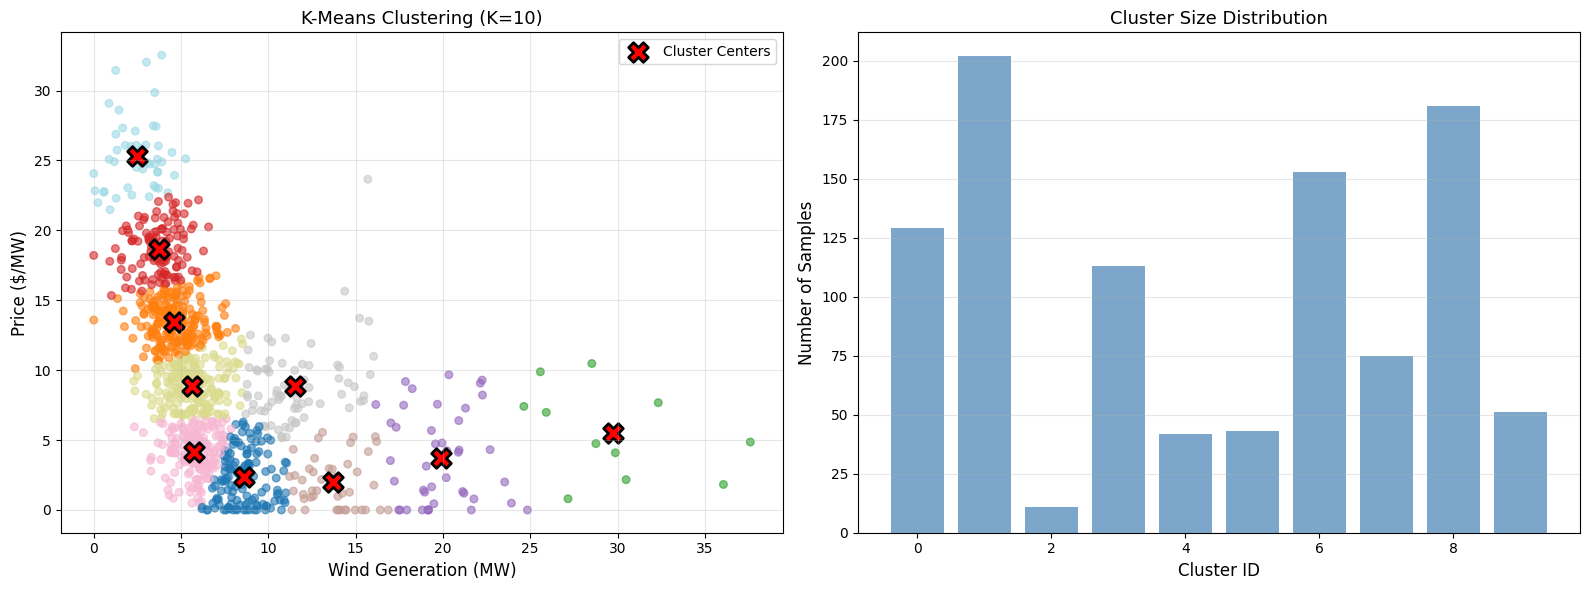

In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

K= 10 

def cluster(joint_dist_df, K):

    # Standardize the data for k-means clustering
    # This ensures both wind and price have equal influence on clustering
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(joint_dist_df[['wind', 'price']])

    # Perform K-means clustering with 
    kmeans = KMeans(n_clusters=K, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)

    # Add cluster labels to the DataFrame
    joint_dist_df['cluster'] = cluster_labels

    # Get cluster centers in original scale
    cluster_centers_scaled = kmeans.cluster_centers_
    cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Clusters with centers
    ax = axes[0]
    scatter = ax.scatter(joint_dist_df['wind'], joint_dist_df['price'], 
                        c=joint_dist_df['cluster'], cmap='tab20', alpha=0.6, s=30)
    ax.scatter(cluster_centers_original[:, 0], cluster_centers_original[:, 1], 
            marker='X', s=200, c='red', edgecolors='black', linewidth=2, label='Cluster Centers')
    ax.set_xlabel('Wind Generation (MW)', fontsize=12)
    ax.set_ylabel('Price ($/MW)', fontsize=12)
    ax.set_title(f'K-Means Clustering (K={K})', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Plot 2: Cluster sizes
    ax = axes[1]
    cluster_sizes = np.bincount(cluster_labels)
    ax.bar(range(len(cluster_sizes)), cluster_sizes, color='steelblue', alpha=0.7)
    ax.set_xlabel('Cluster ID', fontsize=12)
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.set_title('Cluster Size Distribution', fontsize=13)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    cluster_probabilities = joint_dist_df['cluster'].value_counts(normalize=True).sort_index()
    return cluster_probabilities, cluster_centers_original


cluster_probabilities, cluster_centers_original = cluster(joint_dist_df, K)

## Build model